使用Adaptive的方法来达到期望变形,对实验结果的分析

上游代码 -> `ControlPatternAda-Qualysis.py`

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.ticker as ticker
from matplotlib.ticker import MultipleLocator
from matplotlib.gridspec import GridSpec
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import matplotlib.font_manager as fm
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

# 设置全局字体为 Times New Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = 'Times New Roman'

In [103]:
POINTS_NUM:int = 4
num:int = 1
ur_data = pd.read_csv(f'experiment_data{num}.csv')

# 获取并输出列标题
column_titles = ur_data.columns.tolist()
print('Column titles:')
print(column_titles)

loss_np = np.loadtxt(f'loss_list{num}.csv', delimiter=',')
dot_soft_np = np.loadtxt(f'dots_soft_list{num}.csv', delimiter=',')
rob_mov_np = np.loadtxt(f'rob_movement_list{num}.csv', delimiter=',')
ja = np.loadtxt(f'ja_list{num}.csv', delimiter=',')
ja_error = np.loadtxt(f'ja_error_list{num}.csv', delimiter=',')

time = ur_data['timestamp'].to_numpy()
time -= time[0]

Column titles:
['timestamp', 'actual_TCP_pose_0', 'actual_TCP_pose_1', 'actual_TCP_pose_2', 'actual_TCP_pose_3', 'actual_TCP_pose_4', 'actual_TCP_pose_5', 'actual_TCP_speed_0', 'actual_TCP_speed_1', 'actual_TCP_speed_2', 'actual_TCP_speed_3', 'actual_TCP_speed_4', 'actual_TCP_speed_5']


In [11]:
def plot_loss_and_trajectory(loss_np, df, dot_soft_np):
    rob_pose_x = df['actual_TCP_pose_0'].to_numpy()
    rob_pose_y = df['actual_TCP_pose_1'].to_numpy()
    step_num = loss_np.shape[0]
    plot_step_num = 100

    # plot loss
    fig1 = plt.figure(figsize=(9, 3), dpi=100)
    gs = GridSpec(1, 1, figure=fig1)

    # 获取 tab20 颜色映射
    colors = plt.cm.tab20.colors
    # 定义远离红色的颜色（排除红色及其相近颜色）
    filtered_colors = [color for color in colors if not (
        color[0] > 0.8 and color[1] < 0.2 and color[2] < 0.2)]

    # step_num = loss_np.shape[0]
    axs_loss = fig1.add_subplot(gs[0, :])
    for i in range(loss_np.shape[1]):
        axs_loss.plot(loss_np[:plot_step_num, i], marker='.', linestyle='-', color=filtered_colors[i % len(colors)], label=f'Marker {i+1} Loss')
    axs_loss.plot(np.sum(loss_np[:plot_step_num, :], axis=1), marker='.', linestyle='-', color='r', label='Loss Sum')
    axs_loss.set_title('Loss Curve', fontsize=16, fontname='Times New Roman')
    axs_loss.set_xlabel('Time Step', fontsize=14, fontname='Times New Roman')
    axs_loss.set_ylabel('Loss Value', fontsize=14, fontname='Times New Roman')
    axs_loss.set_xlim([-1, plot_step_num])
    axs_loss.xaxis.set_major_locator(MultipleLocator(10))
    axs_loss.ticklabel_format(axis='y', style='sci', scilimits=(-1, 1), useLocale=False, useMathText=True)
    axs_loss.legend(loc='upper right', fontsize=12)
    axs_loss.grid(True)

    plt.tight_layout()

    # plot trajectory
    fig2 = plt.figure(figsize=(10, 3), dpi=100)
    gs = GridSpec(1, 5, figure=fig2)

    indices = np.linspace(0, len(rob_pose_x)-1, step_num, dtype=int)
    indices = indices[:60]
    rows = np.arange(plot_step_num)
    norm = plt.Normalize(rows.min(), rows.max())
    colors = plt.cm.plasma(norm(rows))

    axs_rob_mov = fig2.add_subplot(gs[0, 0])
    rob_pose_xy = np.stack([rob_pose_x[indices], rob_pose_y[indices]], axis=1).reshape(-1, 1, 2)
    segments = np.concatenate([rob_pose_xy[:-1], rob_pose_xy[1:]], axis=1)
    lc = LineCollection(segments * 1000, colors=colors, norm=norm)
    axs_rob_mov.add_collection(lc)
    axs_rob_mov.autoscale()
    axs_rob_mov.set_title('Robot Tool Trajectory', fontsize=14, fontname='Times New Roman')
    # axs_rob_mov.set_xlabel('Y Direction (m)', fontsize=12, fontname='Times New Roman')
    # axs_rob_mov.set_ylabel('X Direction (m)', fontsize=12, fontname='Times New Roman')
    axs_rob_mov.set_aspect('equal', 'datalim')
    axs_rob_mov.grid(True)

    axs_dot_mov_list = []
    for i in range(POINTS_NUM):
        axs_dot_mov = fig2.add_subplot(gs[0, i+1])
        dots_soft = np.stack([dot_soft_np[:, 3*i+1], dot_soft_np[:, 3*i]], axis=1).reshape(-1, 1, 2)
        segments = np.concatenate([dots_soft[:-1], dots_soft[1:]], axis=1)
        lc = LineCollection(segments * 1000, colors=colors, norm=norm)
        axs_dot_mov.add_collection(lc)
        axs_dot_mov.autoscale()
        # axs_dot_mov.plot(dot_soft_np[:, 2*i+1], dot_soft_np[:, 2*i], marker=',', linestyle='-', color=filtered_colors[i % len(colors)], label=f'Dot {i+1}')
        axs_dot_mov.set_title(f'Marker {i+1} Trajectory', fontsize=14, fontname='Times New Roman')
        # axs_dot_mov.set_xlabel('Y Direction (m)', fontsize=12, fontname='Times New Roman')
        # axs_dot_mov.set_ylabel('X Direction (m)', fontsize=12, fontname='Times New Roman')
        axs_dot_mov.set_aspect('equal', 'datalim')
        axs_dot_mov.grid(True)
        axs_dot_mov_list.append(axs_dot_mov)

    plt.tight_layout()

In [9]:
def plot_dot_movement(delta_pos, delta_pos_ada, ja_error):
    step_num = delta_pos.shape[0]
    plot_step_num = 100

    # 获取 tab20 颜色映射
    colors = plt.cm.tab20.colors
    # 定义远离红色的颜色（排除红色及其相近颜色）
    # filtered_colors = [color for color in colors if not (
    #     color[0] > 0.8 and color[1] < 0.2 and color[2] < 0.2)]

    fig1 = plt.figure(figsize=(9, 3), dpi=100)
    gs = GridSpec(1, 1, figure=fig1)

    axs_data = fig1.add_subplot(gs[0, :])
    for i in range(2*POINTS_NUM):
        axs_data.plot(delta_pos[:plot_step_num, i] * 1000, marker=',', linestyle='-', color=colors[i % len(colors)])#, label=f'Dim {i+1}')
        axs_data.plot(delta_pos_ada[1:plot_step_num, i] * 1000, marker=',', linestyle='--', color=colors[i % len(colors)], label=f'Dim {i+1} (Adaptive)')
    axs_data.set_title('Feature Vector Change in Time Step with Adaptive Controller', fontsize=16, fontname='Times New Roman')
    axs_data.set_xlabel('Time Step', fontsize=14, fontname='Times New Roman')
    axs_data.set_ylabel('$\Delta s(k)$ (mm)', fontsize=14, fontname='Times New Roman')
    axs_data.set_xlim([-1, plot_step_num])
    axs_data.xaxis.set_major_locator(MultipleLocator(10))
    axs_data.set_ylim([-0.5, 0.5])
    axs_data.grid(True)
    axs_data.legend(loc='upper right', fontsize=9)

    plt.tight_layout()

    fig2 = plt.figure(figsize=(9, 3), dpi=100)
    gs = GridSpec(1, 1, figure=fig2)
    axs_error = fig2.add_subplot(gs[0, :])
    for i in range(2*POINTS_NUM):
        axs_error.plot(ja_error[1:plot_step_num, i] * 1000, marker=',', linestyle='-', color=colors[i % len(colors)], label=f'Dim {i+1}')
    axs_error.set_title('Feature Vector Change Error of Adaptive Controller', fontsize=16, fontname='Times New Roman')
    axs_error.set_xlabel('Time Step', fontsize=14, fontname='Times New Roman')
    axs_error.set_ylabel('Error $e_s(k)$ (mm)', fontsize=14, fontname='Times New Roman')
    axs_error.set_xlim([-1, plot_step_num])
    axs_error.xaxis.set_major_locator(MultipleLocator(10))
    axs_error.grid(True)
    axs_error.legend(loc='upper right', fontsize=9)

    plt.tight_layout()

---

adaptive controller的学习率为1.e0;

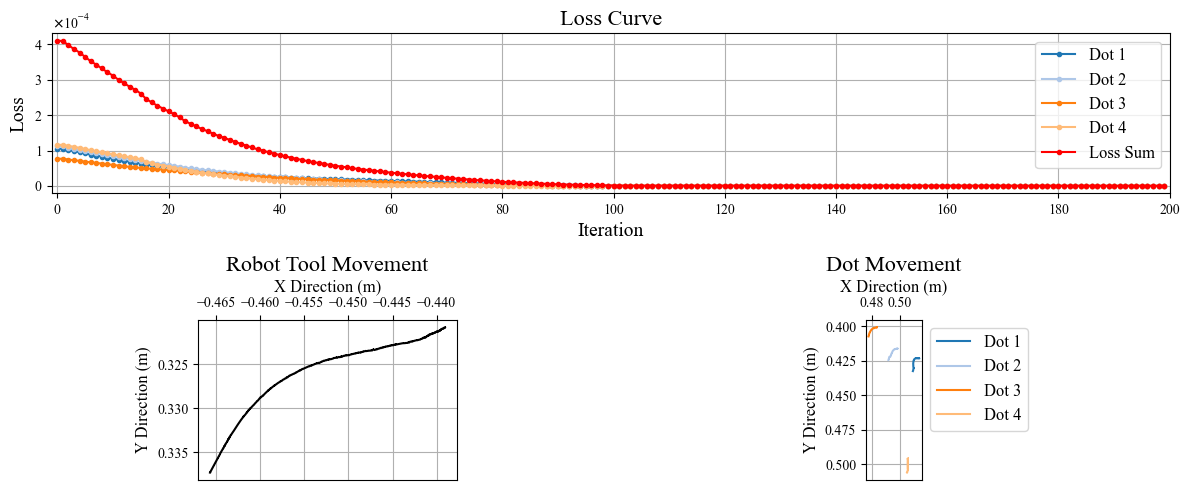

In [ ]:
plot_loss_and_trajectory(loss_np, ur_data, dot_soft_np)

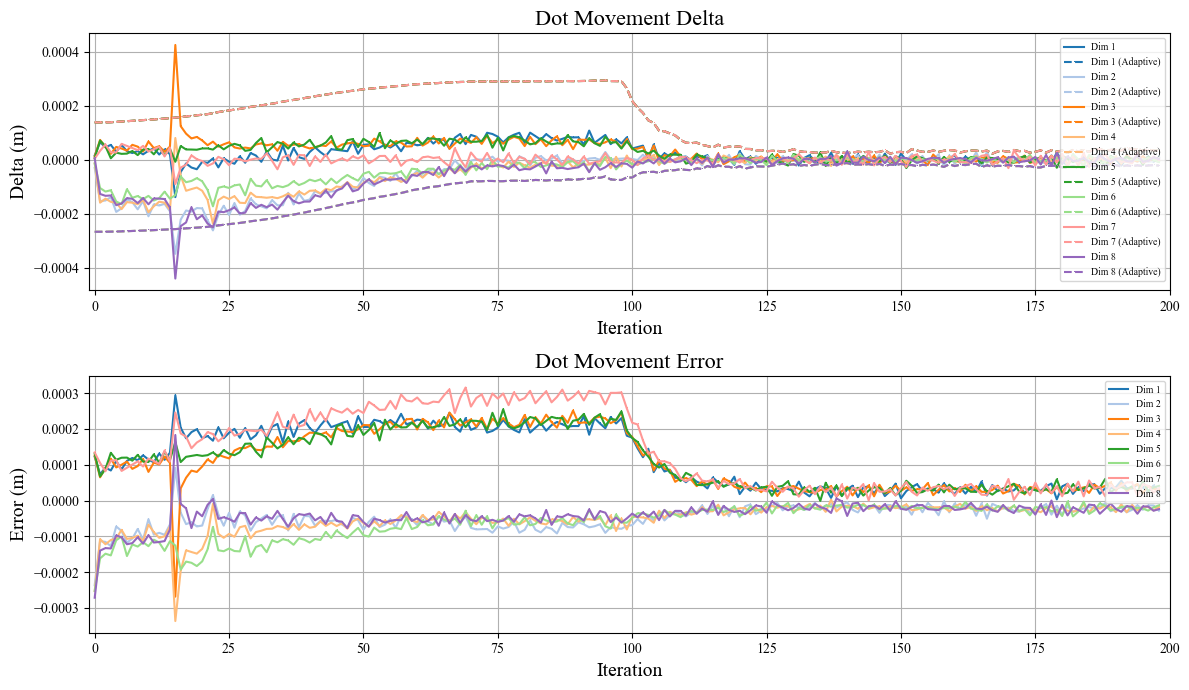

In [97]:
dot_soft_delta = np.diff(dot_soft_np, axis=0)
data_x, data_y = dot_soft_delta[:, 0::3], dot_soft_delta[:, 1::3]
delta_pos = np.zeros((data_x.shape[0], 2*data_x.shape[1]))
delta_pos[:, 0::2] = data_x
delta_pos[:, 1::2] = data_y

delta_pos_ada = np.loadtxt(f'delta_pos_ada_list{num}.csv', delimiter=',')

plot_dot_movement(delta_pos, delta_pos_ada, ja_error)

可以看到Adaptive controller只有一定作用,没有区分接触点的动作对不同Marker点的影响,`Dot Movement Delta`图中所有的虚线退化为两条虚线(表示X和Y方向)

---
Adaptive controller的学习率是1.e1

In [101]:
POINTS_NUM:int = 4
num:int = 2
ur_data = pd.read_csv(f'experiment_data{num}.csv')

# 获取并输出列标题
column_titles = ur_data.columns.tolist()
print('Column titles:')
print(column_titles)

loss_np = np.loadtxt(f'loss_list{num}.csv', delimiter=',')
delta_pos_ada = np.loadtxt(f'delta_pos_ada_list{num}.csv', delimiter=',')
dot_soft_np = np.loadtxt(f'dots_soft_list{num}.csv', delimiter=',')
rob_mov_np = np.loadtxt(f'rob_movement_list{num}.csv', delimiter=',')
ja = np.loadtxt(f'ja_list{num}.csv', delimiter=',')
ja_error = np.loadtxt(f'ja_error_list{num}.csv', delimiter=',')

time = ur_data['timestamp'].to_numpy()
time -= time[0]

Column titles:
['timestamp', 'actual_TCP_pose_0', 'actual_TCP_pose_1', 'actual_TCP_pose_2', 'actual_TCP_pose_3', 'actual_TCP_pose_4', 'actual_TCP_pose_5', 'actual_TCP_speed_0', 'actual_TCP_speed_1', 'actual_TCP_speed_2', 'actual_TCP_speed_3', 'actual_TCP_speed_4', 'actual_TCP_speed_5']


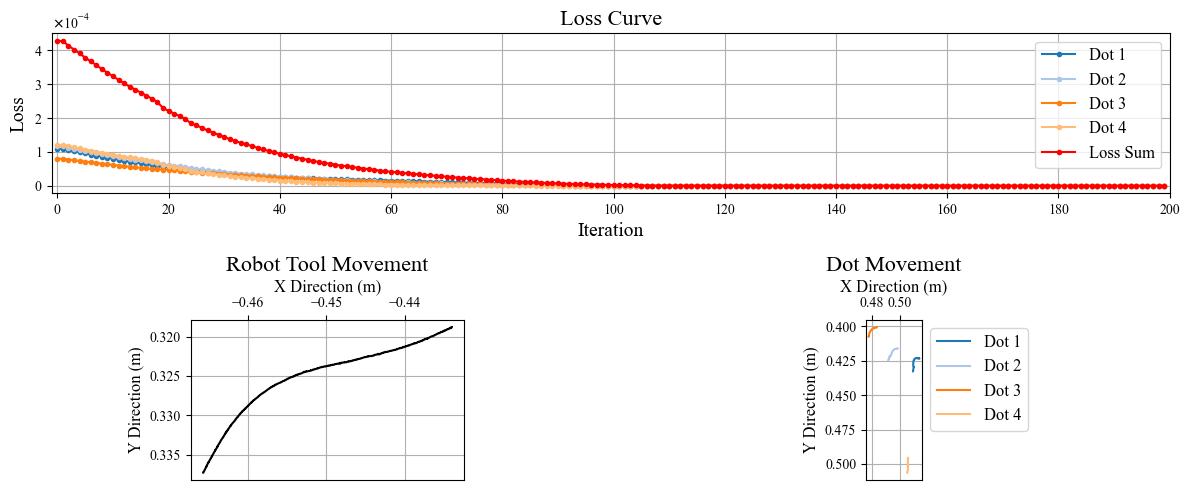

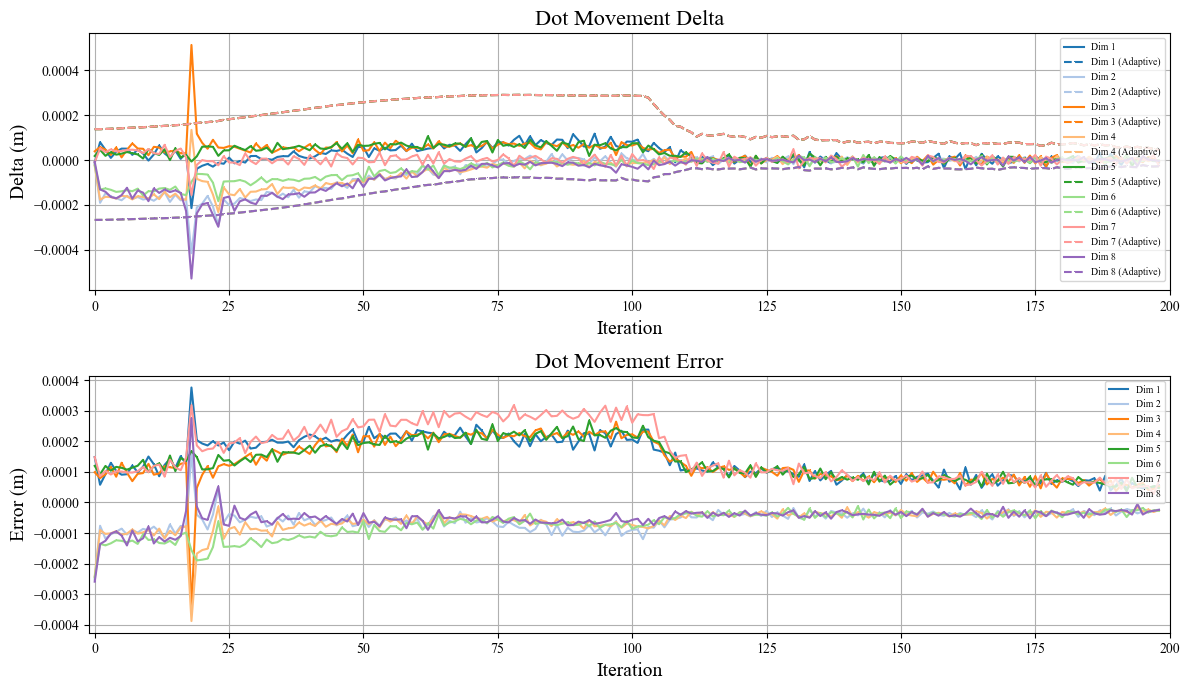

In [100]:
plot_loss_and_trajectory(loss_np, ur_data, dot_soft_np)

dot_soft_delta = np.diff(dot_soft_np, axis=0)
data_x, data_y = dot_soft_delta[:, 0::3], dot_soft_delta[:, 1::3]
delta_pos = np.zeros((data_x.shape[0], 2*data_x.shape[1]))
delta_pos[:, 0::2] = data_x
delta_pos[:, 1::2] = data_y

plot_dot_movement(delta_pos, delta_pos_ada, ja_error)

---
Adaptive Controller的学习率为1.e5，`ja`的参数有了显著的变化

In [90]:
POINTS_NUM:int = 4
num:int = 4
ur_data = pd.read_csv(f'experiment_data{num}.csv')

# 获取并输出列标题
column_titles = ur_data.columns.tolist()
print('Column titles:')
print(column_titles)

loss_np = np.loadtxt(f'loss_list{num}.csv', delimiter=',')
delta_pos_ada = np.loadtxt(f'delta_pos_ada_list{num}.csv', delimiter=',')
dot_soft_np = np.loadtxt(f'dots_soft_list{num}.csv', delimiter=',')
rob_mov_np = np.loadtxt(f'rob_movement_list{num}.csv', delimiter=',')
ja = np.loadtxt(f'ja_list{num}.csv', delimiter=',')
ja_error = np.loadtxt(f'ja_error_list{num}.csv', delimiter=',')

time = ur_data['timestamp'].to_numpy()
time -= time[0]

Column titles:
['timestamp', 'actual_TCP_pose_0', 'actual_TCP_pose_1', 'actual_TCP_pose_2', 'actual_TCP_pose_3', 'actual_TCP_pose_4', 'actual_TCP_pose_5', 'actual_TCP_speed_0', 'actual_TCP_speed_1', 'actual_TCP_speed_2', 'actual_TCP_speed_3', 'actual_TCP_speed_4', 'actual_TCP_speed_5']


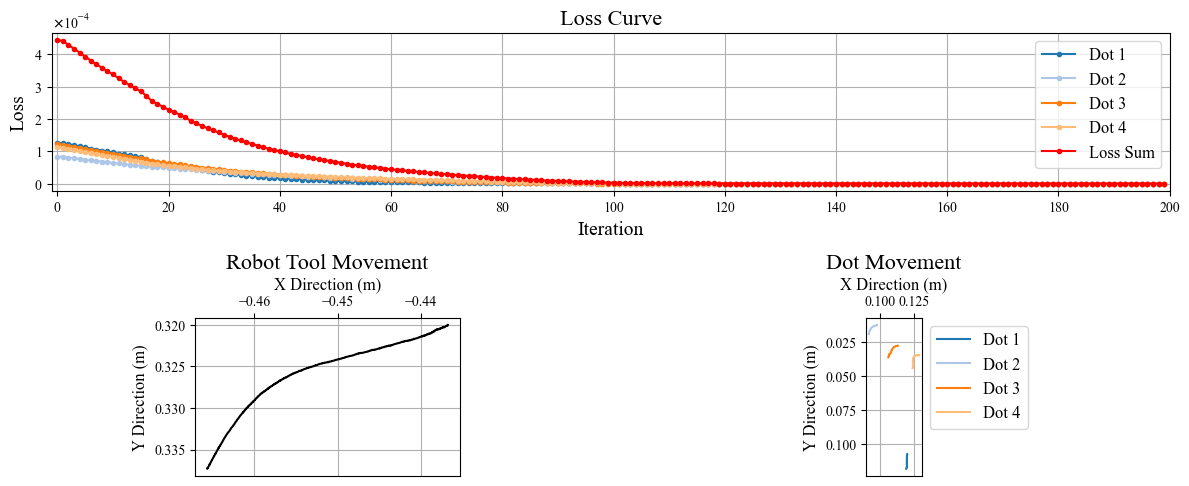

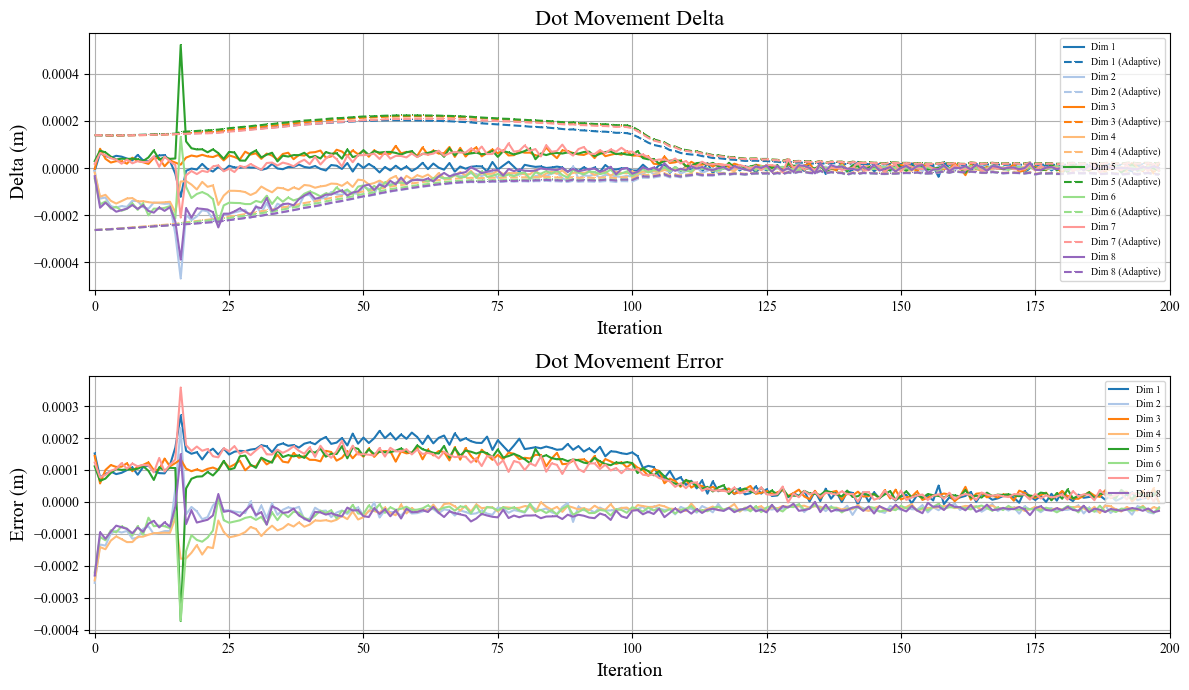

In [107]:
plot_loss_and_trajectory(loss_np, ur_data, dot_soft_np)

dot_soft_delta = np.diff(dot_soft_np, axis=0)
data_x, data_y = dot_soft_delta[:, 0::3], dot_soft_delta[:, 1::3]
delta_pos = np.zeros((data_x.shape[0], 2*data_x.shape[1]))
delta_pos[:, 0::2] = data_x
delta_pos[:, 1::2] = data_y

plot_dot_movement(delta_pos, delta_pos_ada, ja_error)

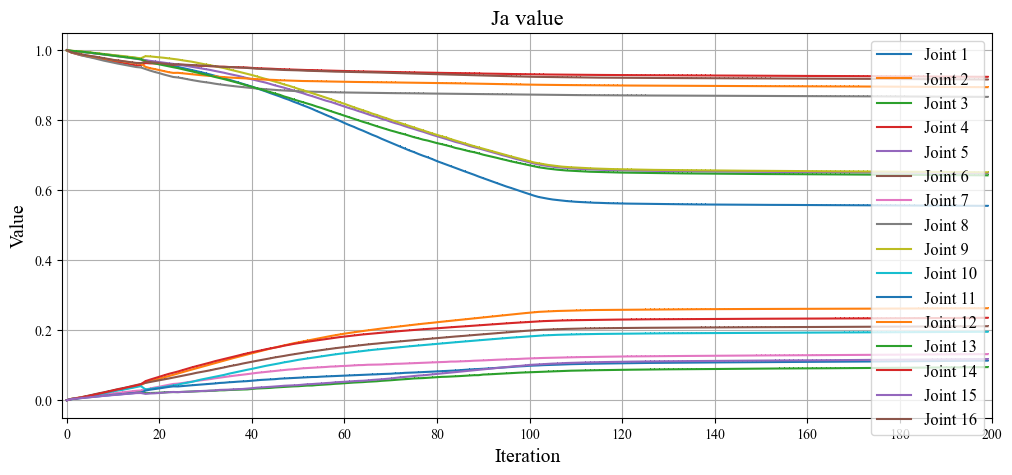

In [110]:
fig = plt.figure(figsize=(12, 5), dpi=100)
gs = GridSpec(1, 1, figure=fig)

axs_ja = fig.add_subplot(gs[0, :])
for i in range(ja.shape[1]):
    axs_ja.plot(ja[:, i], marker=',', linestyle='-', label=f'Joint {i+1}')
axs_ja.set_title('Ja value', fontsize=16, fontname='Times New Roman')
axs_ja.set_xlabel('Iteration', fontsize=14, fontname='Times New Roman')
axs_ja.set_ylabel('Value', fontsize=14, fontname='Times New Roman')
axs_ja.set_xlim([-1, ja.shape[0]])
axs_ja.xaxis.set_major_locator(MultipleLocator(20))
axs_ja.ticklabel_format(axis='y', style='sci', scilimits=(-1, 1), useLocale=False, useMathText=True)
axs_ja.legend(loc='upper right', fontsize=12)
axs_ja.grid(True)

---
Adaptive Controller的学习率为1.e5，机器人的最大动作量为8.e-4

In [7]:
POINTS_NUM:int = 4
num:int = 7
ur_data = pd.read_csv(f'experiment_data{num}.csv')

# 获取并输出列标题
column_titles = ur_data.columns.tolist()
print('Column titles:')
print(column_titles)

loss_np = np.loadtxt(f'loss_list{num}.csv', delimiter=',')
delta_pos_ada = np.loadtxt(f'delta_pos_ada_list{num}.csv', delimiter=',')
dot_soft_np = np.loadtxt(f'dots_soft_list{num}.csv', delimiter=',')
rob_mov_np = np.loadtxt(f'rob_movement_list{num}.csv', delimiter=',')
ja = np.loadtxt(f'ja_list{num}.csv', delimiter=',')
ja_error = np.loadtxt(f'ja_error_list{num}.csv', delimiter=',')

time = ur_data['timestamp'].to_numpy()
time -= time[0]

Column titles:
['timestamp', 'actual_TCP_pose_0', 'actual_TCP_pose_1', 'actual_TCP_pose_2', 'actual_TCP_pose_3', 'actual_TCP_pose_4', 'actual_TCP_pose_5', 'actual_TCP_speed_0', 'actual_TCP_speed_1', 'actual_TCP_speed_2', 'actual_TCP_speed_3', 'actual_TCP_speed_4', 'actual_TCP_speed_5']


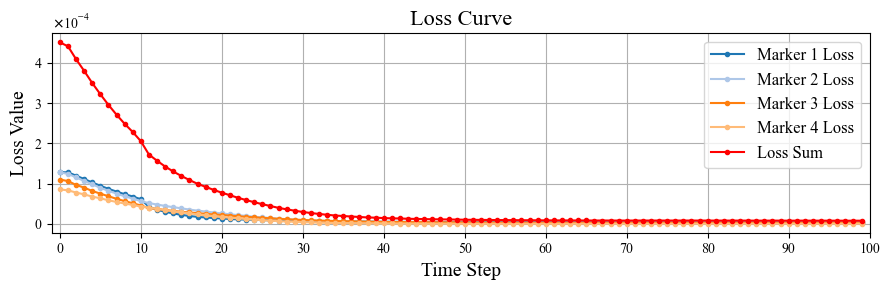

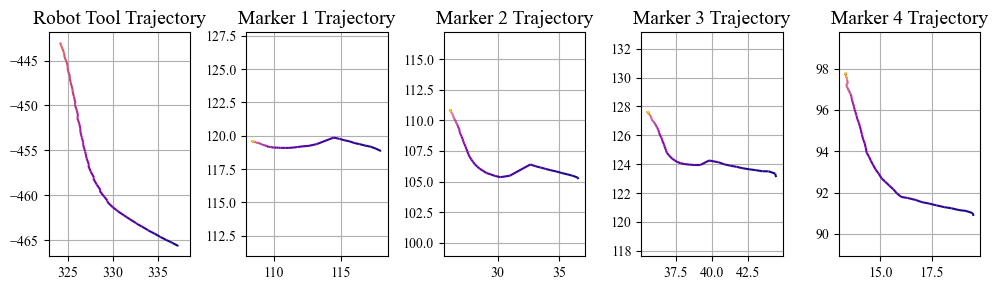

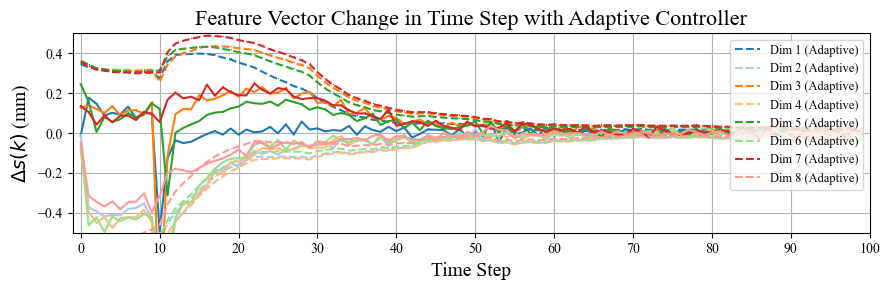

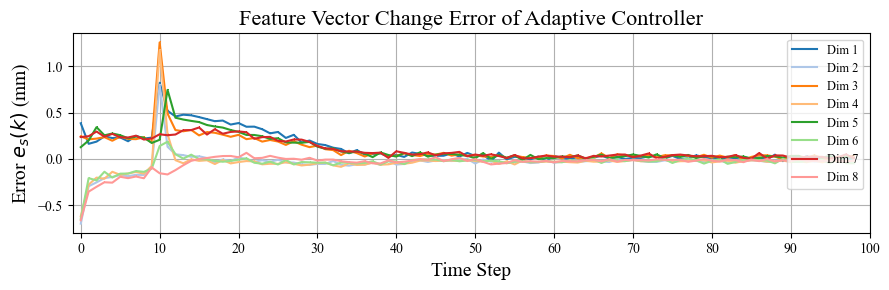

In [12]:
plot_loss_and_trajectory(loss_np, ur_data, dot_soft_np)

dot_soft_delta = np.diff(dot_soft_np, axis=0)
data_x, data_y = dot_soft_delta[:, 0::3], dot_soft_delta[:, 1::3]
delta_pos = np.zeros((data_x.shape[0], 2*data_x.shape[1]))
delta_pos[:, 0::2] = data_x
delta_pos[:, 1::2] = data_y

plot_dot_movement(delta_pos, delta_pos_ada, ja_error)

---
将Adaptive controller中的初始化ja由单位对角阵改为0.3*单位对角阵

In [14]:
POINTS_NUM:int = 4
num:int = 8
ur_data = pd.read_csv(f'experiment_data{num}.csv')

# 获取并输出列标题
column_titles = ur_data.columns.tolist()
print('Column titles:')
print(column_titles)

loss_np = np.loadtxt(f'loss_list{num}.csv', delimiter=',')
delta_pos_ada = np.loadtxt(f'delta_pos_ada_list{num}.csv', delimiter=',')
dot_soft_np = np.loadtxt(f'dots_soft_list{num}.csv', delimiter=',')
rob_mov_np = np.loadtxt(f'rob_movement_list{num}.csv', delimiter=',')
ja = np.loadtxt(f'ja_list{num}.csv', delimiter=',')
ja_error = np.loadtxt(f'ja_error_list{num}.csv', delimiter=',')

time = ur_data['timestamp'].to_numpy()
time -= time[0]

Column titles:
['timestamp', 'actual_TCP_pose_0', 'actual_TCP_pose_1', 'actual_TCP_pose_2', 'actual_TCP_pose_3', 'actual_TCP_pose_4', 'actual_TCP_pose_5', 'actual_TCP_speed_0', 'actual_TCP_speed_1', 'actual_TCP_speed_2', 'actual_TCP_speed_3', 'actual_TCP_speed_4', 'actual_TCP_speed_5']


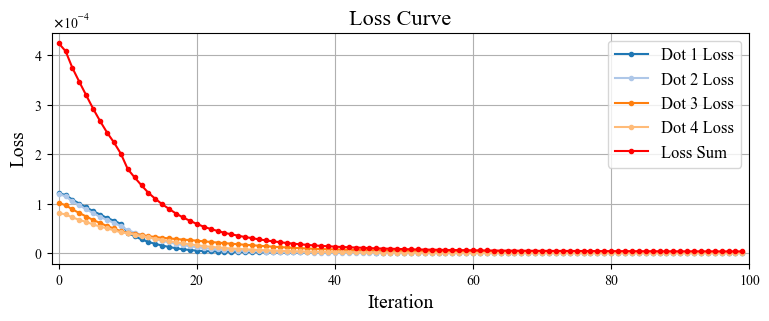

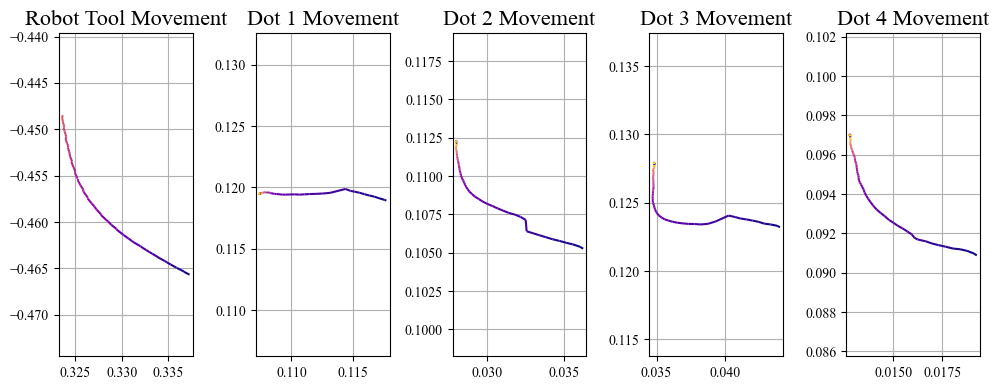

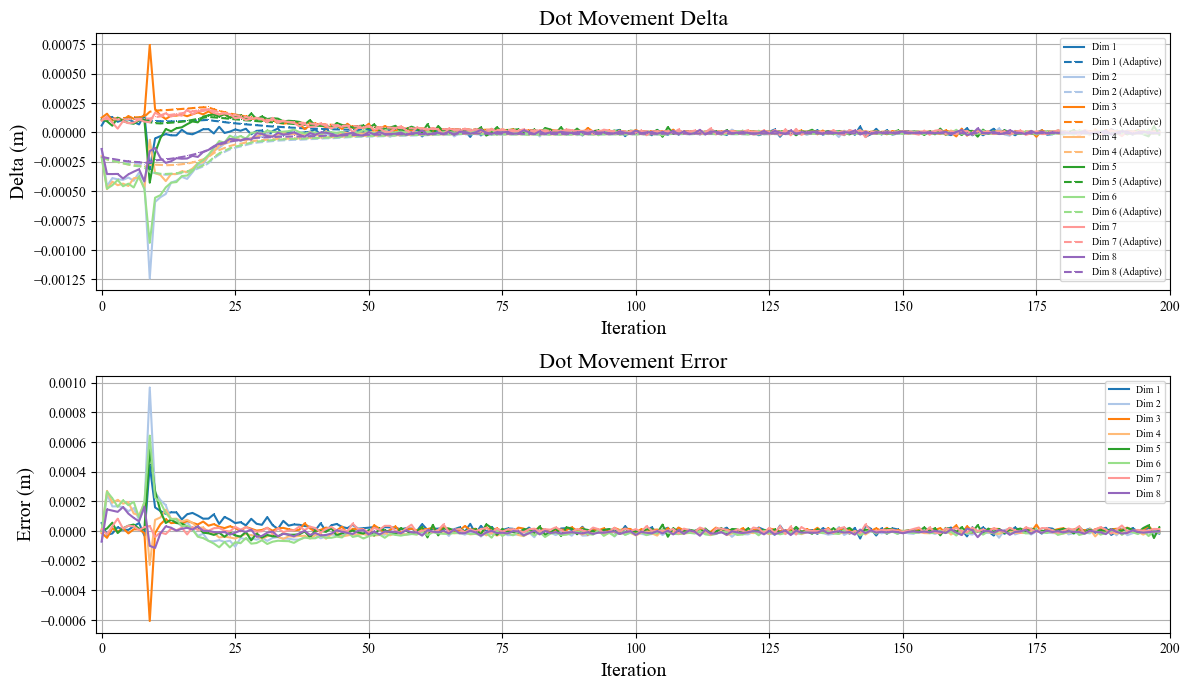

In [39]:
plot_loss_and_trajectory(loss_np, ur_data, dot_soft_np)

dot_soft_delta = np.diff(dot_soft_np, axis=0)
data_x, data_y = dot_soft_delta[:, 0::3], dot_soft_delta[:, 1::3]
delta_pos = np.zeros((data_x.shape[0], 2*data_x.shape[1]))
delta_pos[:, 0::2] = data_x
delta_pos[:, 1::2] = data_y

plot_dot_movement(delta_pos, delta_pos_ada, ja_error)

ja初始化的估计比较合适，所以误差较小

---
将ja初始化为全1矩阵，结果不收敛

In [101]:
POINTS_NUM:int = 4
num:int = 9
ur_data = pd.read_csv(f'experiment_data{num}.csv')

# 获取并输出列标题
column_titles = ur_data.columns.tolist()
print('Column titles:')
print(column_titles)

loss_np = np.loadtxt(f'loss_list{num}.csv', delimiter=',')
delta_pos_ada = np.loadtxt(f'delta_pos_ada_list{num}.csv', delimiter=',')
dot_soft_np = np.loadtxt(f'dots_soft_list{num}.csv', delimiter=',')
rob_mov_np = np.loadtxt(f'rob_movement_list{num}.csv', delimiter=',')
ja = np.loadtxt(f'ja_list{num}.csv', delimiter=',')
ja_error = np.loadtxt(f'ja_error_list{num}.csv', delimiter=',')

time = ur_data['timestamp'].to_numpy()
time -= time[0]

Column titles:
['timestamp', 'actual_TCP_pose_0', 'actual_TCP_pose_1', 'actual_TCP_pose_2', 'actual_TCP_pose_3', 'actual_TCP_pose_4', 'actual_TCP_pose_5', 'actual_TCP_speed_0', 'actual_TCP_speed_1', 'actual_TCP_speed_2', 'actual_TCP_speed_3', 'actual_TCP_speed_4', 'actual_TCP_speed_5']


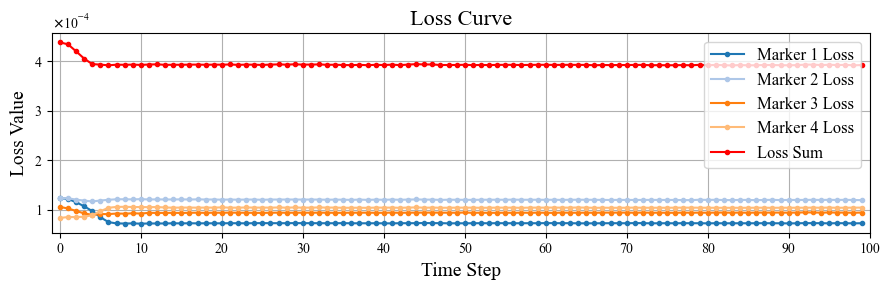

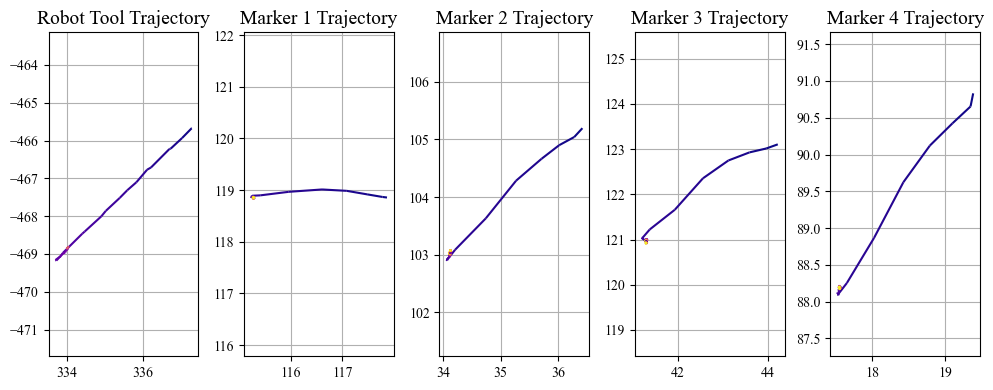

In [102]:
plot_loss_and_trajectory(loss_np, ur_data, dot_soft_np)

---
用于论文绘图

Column titles:
['timestamp', 'actual_TCP_pose_0', 'actual_TCP_pose_1', 'actual_TCP_pose_2', 'actual_TCP_pose_3', 'actual_TCP_pose_4', 'actual_TCP_pose_5', 'actual_TCP_speed_0', 'actual_TCP_speed_1', 'actual_TCP_speed_2', 'actual_TCP_speed_3', 'actual_TCP_speed_4', 'actual_TCP_speed_5']


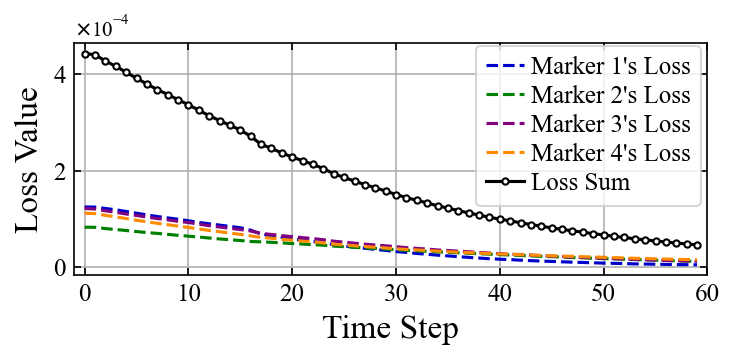

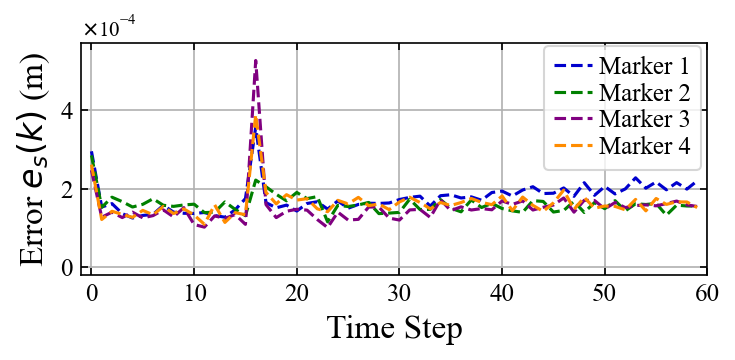

In [4]:
POINTS_NUM:int = 4
num:int = 4
ur_data = pd.read_csv(f'experiment_data{num}.csv')

# 获取并输出列标题
column_titles = ur_data.columns.tolist()
print('Column titles:')
print(column_titles)

loss_np = np.loadtxt(f'loss_list{num}.csv', delimiter=',')
delta_pos_ada = np.loadtxt(f'delta_pos_ada_list{num}.csv', delimiter=',')
dot_soft_np = np.loadtxt(f'dots_soft_list{num}.csv', delimiter=',')
rob_mov_np = np.loadtxt(f'rob_movement_list{num}.csv', delimiter=',')
ja = np.loadtxt(f'ja_list{num}.csv', delimiter=',')
ja_error = np.loadtxt(f'ja_error_list{num}.csv', delimiter=',')

time = ur_data['timestamp'].to_numpy()
time -= time[0]
plot_step_num = 60

fig_loss = plt.figure(figsize=(5, 2.5), dpi=150)
gs = GridSpec(1, 1, figure=fig_loss)

axs_loss = fig_loss.add_subplot(gs[0, :])
# for i in range(loss_np.shape[1]):
#     axs_loss.plot(loss_np[:plot_step_num, i], marker='.', linestyle='-', color=filtered_colors[i % len(colors)], label=f'Marker {i+1} Loss')
axs_loss.plot(loss_np[:plot_step_num, 0], marker='', markerfacecolor='white', linestyle='--', color='mediumblue', label='Marker 1\'s Loss')
axs_loss.plot(loss_np[:plot_step_num, 1], marker='', markerfacecolor='white', linestyle='--', color='green', label='Marker 2\'s Loss')
axs_loss.plot(loss_np[:plot_step_num, 2], marker='', markerfacecolor='white', linestyle='--', color='purple', label='Marker 3\'s Loss')
axs_loss.plot(loss_np[:plot_step_num, 3], marker='', markerfacecolor='white', linestyle='--', color='darkorange', label='Marker 4\'s Loss')
axs_loss.plot(np.sum(loss_np[:plot_step_num], axis=1), marker='.', markerfacecolor='white', linestyle='-', color='black', label='Loss Sum')
# axs_loss.set_title('Loss Curve', fontsize=16, fontname='Times New Roman')
axs_loss.set_xlabel('Time Step', fontsize=16, fontname='Times New Roman')
axs_loss.set_ylabel('Loss Value', fontsize=16, fontname='Times New Roman')
axs_loss.set_xlim([-1, plot_step_num])
axs_loss.xaxis.set_major_locator(MultipleLocator(10))
axs_loss.ticklabel_format(axis='y', style='sci', scilimits=(-1, 1), useLocale=False, useMathText=True)
axs_loss.tick_params(axis='both', labelsize=12, direction='in', top=True, right=True)
axs_loss.grid(True)
axs_loss.legend(handlelength=1.5, handletextpad=0.3, labelspacing=0.2, loc='upper right', fontsize=12, bbox_to_anchor=(1.01, 1.04), bbox_transform=axs_loss.transAxes)

plt.tight_layout()
fig_loss.savefig('exp-servo-success-loss.svg', transparent=True, dpi=300, bbox_inches='tight')

fig_feature_err = plt.figure(figsize=(5, 2.5), dpi=150)
gs = GridSpec(1, 1, figure=fig_feature_err)
axs_error = fig_feature_err.add_subplot(gs[0, :])

feature_error = np.zeros((plot_step_num, POINTS_NUM))
for idx in range(POINTS_NUM):
    feature_error[:, idx] = np.linalg.norm(ja_error[1:plot_step_num+1, 2*idx:2*(idx+1)], axis=1)

axs_error.plot(feature_error[:, 0], marker='', markerfacecolor='white', linestyle='--', color='mediumblue', label='Marker 1')
axs_error.plot(feature_error[:, 1], marker='', markerfacecolor='white', linestyle='--', color='green', label='Marker 2')
axs_error.plot(feature_error[:, 2], marker='', markerfacecolor='white', linestyle='--', color='purple', label='Marker 3')
axs_error.plot(feature_error[:, 3], marker='', markerfacecolor='white', linestyle='--', color='darkorange', label='Marker 4')
# axs_error.set_title('Feature Vector Change Error of Model Method', fontsize=16, fontname='Times New Roman')
axs_error.set_xlabel('Time Step', fontsize=16, fontname='Times New Roman')
axs_error.set_ylabel('Error $e_s(k)$ (m)', fontsize=16, fontname='Times New Roman')
axs_error.xaxis.set_major_locator(MultipleLocator(10))
axs_error.set_xlim([-1, plot_step_num])
axs_error.set_ylim([-0.2e-4, 5.7e-4])
axs_error.ticklabel_format(axis='y', style='sci', scilimits=(-1, 1), useLocale=False, useMathText=True)
axs_error.tick_params(axis='both', labelsize=12, direction='in', top=True, right=True)
axs_error.grid(True)
axs_error.legend(handlelength=1.5, handletextpad=0.3, labelspacing=0.1, loc='upper right', fontsize=12, bbox_to_anchor=(1.01, 1.04), bbox_transform=axs_error.transAxes)

plt.tight_layout()
fig_feature_err.savefig('exp-servo-success-err.svg', transparent=True, dpi=300, bbox_inches='tight')

In [4]:
f_error = np.mean(feature_error, axis=0)

Column titles:
['timestamp', 'actual_TCP_pose_0', 'actual_TCP_pose_1', 'actual_TCP_pose_2', 'actual_TCP_pose_3', 'actual_TCP_pose_4', 'actual_TCP_pose_5', 'actual_TCP_speed_0', 'actual_TCP_speed_1', 'actual_TCP_speed_2', 'actual_TCP_speed_3', 'actual_TCP_speed_4', 'actual_TCP_speed_5']


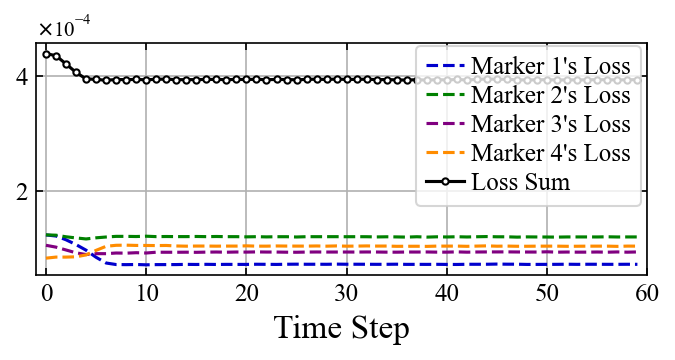

In [39]:
POINTS_NUM:int = 4
num:int = 9
ur_data = pd.read_csv(f'experiment_data{num}.csv')

# 获取并输出列标题
column_titles = ur_data.columns.tolist()
print('Column titles:')
print(column_titles)

loss_np = np.loadtxt(f'loss_list{num}.csv', delimiter=',')
delta_pos_ada = np.loadtxt(f'delta_pos_ada_list{num}.csv', delimiter=',')
dot_soft_np = np.loadtxt(f'dots_soft_list{num}.csv', delimiter=',')
rob_mov_np = np.loadtxt(f'rob_movement_list{num}.csv', delimiter=',')
ja = np.loadtxt(f'ja_list{num}.csv', delimiter=',')
ja_error = np.loadtxt(f'ja_error_list{num}.csv', delimiter=',')

time = ur_data['timestamp'].to_numpy()
time -= time[0]
plot_step_num = 60

# plot loss
fig_loss = plt.figure(figsize=(4.6, 2.5), dpi=150)
gs = GridSpec(1, 1, figure=fig_loss)

axs_loss = fig_loss.add_subplot(gs[0, :])
# for i in range(loss_np.shape[1]):
#     axs_loss.plot(loss_np[:plot_step_num, i], marker='.', linestyle='-', color=filtered_colors[i % len(colors)], label=f'Marker {i+1} Loss')
axs_loss.plot(loss_np[:plot_step_num, 0], marker='', markerfacecolor='white', linestyle='--', color='mediumblue', label='Marker 1\'s Loss')
axs_loss.plot(loss_np[:plot_step_num, 1], marker='', markerfacecolor='white', linestyle='--', color='green', label='Marker 2\'s Loss')
axs_loss.plot(loss_np[:plot_step_num, 2], marker='', markerfacecolor='white', linestyle='--', color='purple', label='Marker 3\'s Loss')
axs_loss.plot(loss_np[:plot_step_num, 3], marker='', markerfacecolor='white', linestyle='--', color='darkorange', label='Marker 4\'s Loss')
axs_loss.plot(np.sum(loss_np[:plot_step_num], axis=1), marker='.', markerfacecolor='white', linestyle='-', color='black', label='Loss Sum')
# axs_loss.set_title('Loss Curve', fontsize=16, fontname='Times New Roman')
axs_loss.set_xlabel('Time Step', fontsize=16, fontname='Times New Roman')
# axs_loss.set_ylabel('Loss Value', fontsize=16, fontname='Times New Roman')
axs_loss.set_xlim([-1, plot_step_num])
axs_loss.xaxis.set_major_locator(MultipleLocator(10))
axs_loss.ticklabel_format(axis='y', style='sci', scilimits=(-1, 1), useLocale=False, useMathText=True)
axs_loss.tick_params(axis='both', labelsize=12, direction='in', top=True, right=True)
axs_loss.grid(True)
axs_loss.legend(handlelength=1.5, handletextpad=0.3, labelspacing=0.2, loc='upper right', fontsize=12, bbox_to_anchor=(1.01, 1.04), bbox_transform=axs_loss.transAxes)

plt.tight_layout()
fig_loss.savefig('exp-servo-failed-loss.svg', transparent=True, dpi=300, bbox_inches='tight')